# Part 2: Univariate analysis
- **Data:** `data/listings_clean.csv` from `01_cleaning.ipynb` (92,635 listings, 69 columns).
- **Goal:** describe each variable on its own (shape, center, spread, skew, outliers) before the bivariate and multivariate parts relate them to `top_rated`.
- **Samples:** general variables use all listings. Anything about the rating uses rated listings only (70,708).
- **Not used:** host response rate, acceptance rate and response time are empty in this snapshot. Review sub-scores and `host_is_superhost` are leakage for the model, so they are only described here, never used as features.

In [1]:
import json
from statistics import NormalDist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

BLUE, GREY, RED = "#2471A3", "#95A5A6", "#C0392B"

df = pd.read_csv("../data/listings_clean.csv", low_memory=False)
rated = df[df["top_rated"].notna()]
print(df.shape, "rated:", len(rated))


def clean_axes(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)


def bucket_counts(s, cap, fmt="{:g}"):
    # Share (%) of each value, with everything at or above `cap` grouped as "cap+"
    s = s.dropna()
    lab = s.where(s < cap, cap).map(lambda v: fmt.format(v) + ("+" if v >= cap else ""))
    order = sorted(lab.unique(), key=lambda x: float(x.rstrip("+")))
    return (lab.value_counts(normalize=True) * 100).reindex(order)


def bar_pct(ax, share, color=BLUE, horizontal=False):
    bars = (ax.barh if horizontal else ax.bar)(share.index.astype(str), share.values, color=color)
    ax.bar_label(bars, labels=[f"{v:.0f}%" if v >= 1 else "<1%" for v in share.values],
                 padding=2, fontsize=7)
    clean_axes(ax)
    return bars


def iqr_fences(s):
    # Tukey fences: values outside Q1 - 1.5*IQR and Q3 + 1.5*IQR count as outliers
    q1, q3 = s.quantile([0.25, 0.75])
    return q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)


def n_outside(s):
    lo, hi = iqr_fences(s)
    return int(((s < lo) | (s > hi)).sum())


def box_h(ax, s, color=BLUE):
    # Horizontal box plot; points beyond the 1.5*IQR whiskers drawn small and faint
    ax.boxplot(s, orientation="horizontal", widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.35, edgecolor=color),
               medianprops=dict(color=RED), whiskerprops=dict(color=color), capprops=dict(color=color),
               flierprops=dict(marker=".", markersize=2, markerfacecolor=GREY, markeredgecolor="none", alpha=0.3))
    ax.set_yticks([])
    clean_axes(ax)


def qq_normal(ax, s, color=BLUE, n=400):
    # Standardised data quantiles against normal quantiles; points on the dashed line mean a normal shape
    probs = (np.arange(1, n + 1) - 0.5) / n
    theo = np.array([NormalDist().inv_cdf(q) for q in probs])
    z = (s - s.mean()) / s.std()
    ax.scatter(theo, np.quantile(z, probs), s=6, color=color)
    ax.plot([theo[0], theo[-1]], [theo[0], theo[-1]], color=RED, ls="--", lw=1)
    ax.set_xlabel("Normal quantiles")
    ax.set_ylabel("Data quantiles (z-score)")
    clean_axes(ax)

(92635, 69) rated: 70708


## Step 1: Summary statistics
Center, spread, skew and tails of the main numeric variables.
- **Skew** above 1 means a long right tail (below -1, a long left tail); these variables need log scales or grouping in charts.
- **Kurtosis** is excess kurtosis: 0 for a normal distribution, above 3 means heavy tails with many extreme values.
- **IQR fences** are Q1 - 1.5·IQR and Q3 + 1.5·IQR; `n_outliers` counts listings outside them. Step 2 judges whether the extremes are real.

In [2]:
num_cols = ["review_scores_rating", "price_capped", "accommodates", "bedrooms", "beds", "bathrooms",
            "minimum_nights", "availability_365", "number_of_reviews", "reviews_per_month",
            "estimated_occupancy_l365d", "calculated_host_listings_count", "hosts_time_as_host_years"]
summary = df[num_cols].describe().T
summary["missing_pct"] = (df[num_cols].isna().mean() * 100).round(1)
summary["skew"] = df[num_cols].skew()
summary["kurtosis"] = df[num_cols].kurt()
summary[["iqr_low", "iqr_high"]] = [iqr_fences(df[c].dropna()) for c in num_cols]
summary["n_outliers"] = [n_outside(df[c].dropna()) for c in num_cols]
summary["outlier_pct"] = summary["n_outliers"] / summary["count"] * 100
display(summary.round(2))

heavy = summary["kurtosis"].sort_values(ascending=False)
most_out = summary["outlier_pct"].sort_values(ascending=False)
display(Markdown(
    f"**Insight:** {(summary['kurtosis'] > 3).sum()} of {len(num_cols)} variables have excess kurtosis above 3 (heavy tails), "
    f"led by `{heavy.index[0]}` ({heavy.iloc[0]:,.0f}) and `{heavy.index[1]}` ({heavy.iloc[1]:,.0f}). "
    f"The IQR fences flag the largest share of listings in `{most_out.index[0]}` ({most_out.iloc[0]:.0f}%) and "
    f"`{most_out.index[1]}` ({most_out.iloc[1]:.0f}%). For skewed variables most of these points are the normal long tail, "
    f"not errors, so they are not removed on the fence rule alone. Only `availability_365` and `hosts_time_as_host_years` "
    f"have negative kurtosis (flat, no outliers)."))

,count,mean,std,min,25%,50%,75%,max,missing_pct,skew,kurtosis,iqr_low,iqr_high,n_outliers,outlier_pct
review_scores_rating,70708.0,4.69,0.48,1.00,4.60,4.83,5.00,5.00,23.7,-3.94,22.17,4.00,5.60,2840,4.02
price_capped,62238.0,244.37,225.07,2.23,100.00,180.00,300.10,1373.46,32.8,2.54,8.14,-200.15,600.24,3963,6.37
accommodates,92635.0,3.39,2.12,1.00,2.00,3.00,4.00,16.00,0.0,1.62,4.00,-1.00,7.00,4848,5.23
bedrooms,68653.0,1.77,1.04,0.00,1.00,1.00,2.00,30.00,25.9,2.92,32.76,-0.50,3.50,4523,6.59
beds,60161.0,2.02,1.45,1.00,1.00,2.00,3.00,50.00,35.1,3.38,38.40,-2.00,6.00,847,1.41
bathrooms,92509.0,1.33,0.69,0.00,1.00,1.00,1.50,30.00,0.1,4.79,87.21,0.25,2.25,7393,7.99
minimum_nights,92630.0,4.56,20.90,1.00,1.00,2.00,3.00,1125.00,0.0,26.13,1011.93,-2.00,6.00,9231,9.97
availability_365,92635.0,152.66,141.13,0.00,0.00,127.00,301.00,365.00,0.0,0.25,-1.58,-451.50,752.50,0,0.00
number_of_reviews,92635.0,24.15,55.08,0.00,1.00,5.00,23.00,1959.00,0.0,6.52,82.87,-32.00,56.00,10574,11.41
reviews_per_month,70711.0,0.99,1.32,0.01,0.14,0.49,1.28,32.17,23.7,3.13,22.05,-1.57,2.99,5683,8.04


**Insight:** 10 of 13 variables have excess kurtosis above 3 (heavy tails), led by `minimum_nights` (1,012) and `bathrooms` (87). The IQR fences flag the largest share of listings in `calculated_host_listings_count` (15%) and `estimated_occupancy_l365d` (12%). For skewed variables most of these points are the normal long tail, not errors, so they are not removed on the fence rule alone. Only `availability_365` and `hosts_time_as_host_years` have negative kurtosis (flat, no outliers).

## Figure 5: The target, overall rating
Shows how ratings are spread, how the 4.8 cut point splits rated listings into the two classes, and how far the shape is from normal (box and QQ plots).

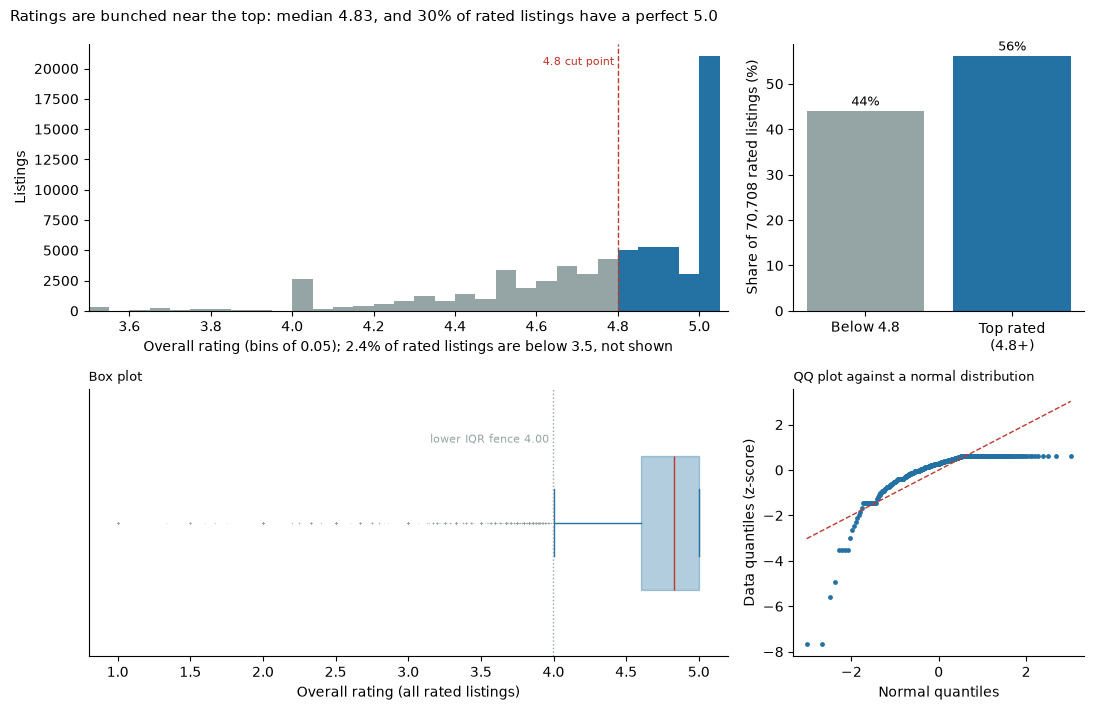

**Insight:** the rating is strongly left-skewed (skew -3.9); the middle half of rated listings lies between 4.60 and 5.00, and only 4% score below 4.0. The 4.8 cut point gives fairly balanced classes (56% vs 44%), so the model does not need resampling, but the classes are separated by small rating differences. Kurtosis is 22: 2,840 listings (4%) sit below the lower IQR fence of 4.00. These are real guest scores, so they are kept. The QQ plot bends away from the line at both ends: a long lower tail and a flat top where scores hit the 5.0 ceiling. No transform removes a ceiling, which is why the rating is used as a binary target (`top_rated`) rather than a number.

In [3]:
rt = rated["review_scores_rating"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), gridspec_kw={"width_ratios": [2.2, 1]})
axes = axes.ravel()

ax = axes[0]
edges = np.linspace(1, 5.05, 82)  # 0.05-wide bins, last bin holds exactly 5.0
_, _, patches = ax.hist(rt, bins=edges, color=GREY)
for p in patches:
    if p.get_x() >= 4.8 - 1e-9:
        p.set_facecolor(BLUE)
ax.axvline(4.8, color=RED, ls="--", lw=1)
ax.text(4.79, ax.get_ylim()[1] * 0.92, "4.8 cut point", ha="right", fontsize=8, color=RED)
ax.set_xlim(3.5, 5.07)
ax.set_xlabel(f"Overall rating (bins of 0.05); {(rt < 3.5).mean() * 100:.1f}% of rated listings are below 3.5, not shown")
ax.set_ylabel("Listings")
clean_axes(ax)

ax = axes[1]
target_share = rated["top_rated"].map({1: "Top rated\n(4.8+)", 0: "Below 4.8"}).value_counts(normalize=True) * 100
target_share = target_share.reindex(["Below 4.8", "Top rated\n(4.8+)"])
bars = ax.bar(target_share.index, target_share.values, color=[GREY, BLUE])
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in target_share.values], padding=2, fontsize=9)
ax.set_ylabel(f"Share of {len(rated):,} rated listings (%)")
clean_axes(ax)

lo_r, _ = iqr_fences(rt)
ax = axes[2]
box_h(ax, rt)
ax.axvline(lo_r, color=GREY, ls=":", lw=1)
ax.text(lo_r - 0.03, 1.3, f"lower IQR fence {lo_r:.2f}", ha="right", fontsize=8, color=GREY)
ax.set_xlabel("Overall rating (all rated listings)")
ax.set_title("Box plot", loc="left", fontsize=9)

ax = axes[3]
qq_normal(ax, rt)
ax.set_title("QQ plot against a normal distribution", loc="left", fontsize=9)

fig.suptitle(f"Ratings are bunched near the top: median {rt.median():.2f}, and {(rt == 5).mean() * 100:.0f}% "
             f"of rated listings have a perfect 5.0", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig5_rating_distribution.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** the rating is strongly left-skewed (skew {rt.skew():.1f}); the middle half of rated listings lies between "
    f"{rt.quantile(0.25):.2f} and {rt.quantile(0.75):.2f}, and only {(rt < 4).mean() * 100:.0f}% score below 4.0. The 4.8 cut point gives fairly balanced classes "
    f"({target_share.iloc[1]:.0f}% vs {target_share.iloc[0]:.0f}%), so the model does not need resampling, but the classes are "
    f"separated by small rating differences. Kurtosis is {rt.kurt():.0f}: {n_outside(rt):,} listings "
    f"({n_outside(rt) / len(rt) * 100:.0f}%) sit below the lower IQR fence of {lo_r:.2f}. These are real guest scores, so they are kept. "
    f"The QQ plot bends away from the line at both ends: a long lower tail and a flat top where scores hit the 5.0 ceiling. "
    f"No transform removes a ceiling, which is why the rating is used as a binary target (`top_rated`) rather than a number."))

## Figure 6: Nightly price, before and after the log transform
Uses `price_capped` (top 1% capped in cleaning). Price is missing for 32.8% of listings, which are mostly listings that cannot be booked. Each row shows the same prices as a histogram, a box plot and a QQ plot; the top row is raw, the bottom row is log price.

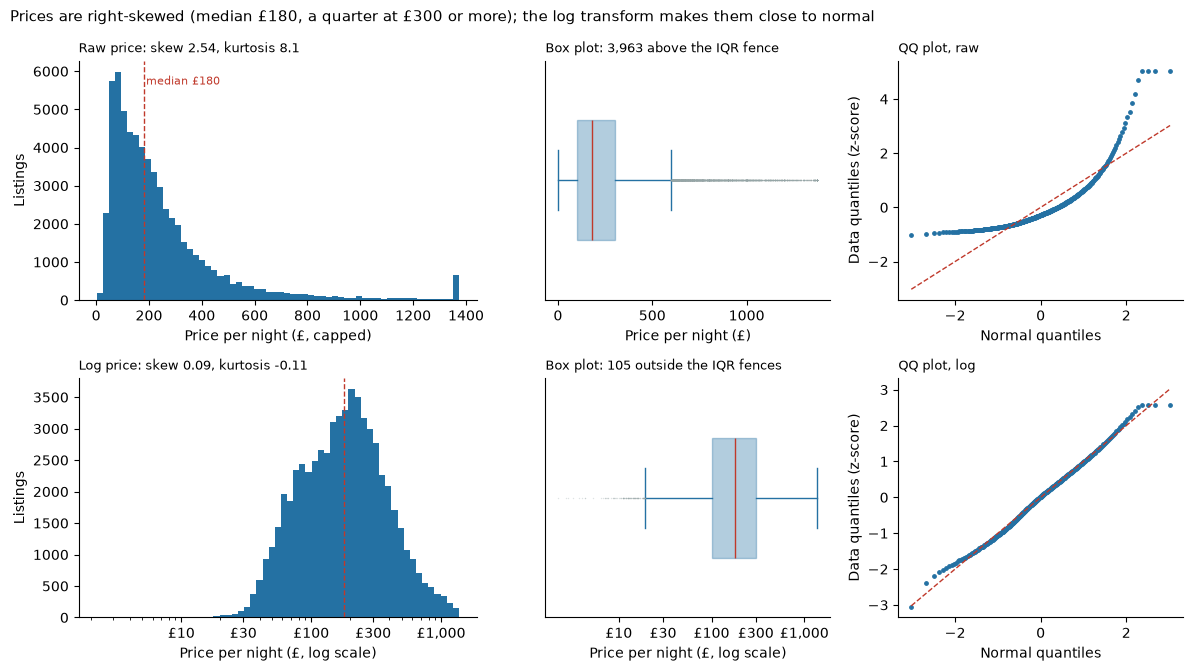

**Insight:** based on 62,238 priced listings, raw price has skew 2.54 and kurtosis 8.1 even after capping, and 3,963 listings (6%) sit above the upper IQR fence of £600. After the log transform, skew is 0.09 and kurtosis -0.11 (a normal distribution has 0 for both), the QQ points follow the line through the middle of the range, and the fence count falls to 105.

**Decision:** price is analysed as **log(price)** from here on. The bivariate and multivariate parts should use `np.log(price_capped)`; raw £ values are only used for labels that readers need in pounds.

In [4]:
p = df["price_capped"].dropna()
lp = np.log(p)
ticks = [10, 30, 100, 300, 1000]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.8), gridspec_kw={"width_ratios": [1.4, 1, 1]})

ax = axes[0, 0]
ax.hist(p, bins=60, color=BLUE)
ax.axvline(p.median(), color=RED, ls="--", lw=1)
ax.text(p.median() * 1.05, ax.get_ylim()[1] * 0.9, f"median £{p.median():.0f}", fontsize=8, color=RED)
ax.set_xlabel("Price per night (£, capped)")
ax.set_ylabel("Listings")
ax.set_title(f"Raw price: skew {p.skew():.2f}, kurtosis {p.kurt():.1f}", loc="left", fontsize=9)
clean_axes(ax)

ax = axes[1, 0]
ax.hist(p, bins=np.logspace(np.log10(p.min()), np.log10(p.max()), 60), color=BLUE)
ax.set_xscale("log")
ax.set_xticks(ticks)
ax.set_xticklabels([f"£{t:,}" for t in ticks])
ax.axvline(p.median(), color=RED, ls="--", lw=1)
ax.set_xlabel("Price per night (£, log scale)")
ax.set_ylabel("Listings")
ax.set_title(f"Log price: skew {lp.skew():.2f}, kurtosis {lp.kurt():.2f}", loc="left", fontsize=9)
clean_axes(ax)

box_h(axes[0, 1], p)
axes[0, 1].set_xlabel("Price per night (£)")
axes[0, 1].set_title(f"Box plot: {n_outside(p):,} above the IQR fence", loc="left", fontsize=9)
box_h(axes[1, 1], lp)
axes[1, 1].set_xticks(np.log(ticks))
axes[1, 1].set_xticklabels([f"£{t:,}" for t in ticks])
axes[1, 1].set_xlabel("Price per night (£, log scale)")
axes[1, 1].set_title(f"Box plot: {n_outside(lp):,} outside the IQR fences", loc="left", fontsize=9)

qq_normal(axes[0, 2], p)
axes[0, 2].set_title("QQ plot, raw", loc="left", fontsize=9)
qq_normal(axes[1, 2], lp)
axes[1, 2].set_title("QQ plot, log", loc="left", fontsize=9)

fig.suptitle(f"Prices are right-skewed (median £{p.median():.0f}, a quarter at £{p.quantile(0.75):.0f} or more); "
             f"the log transform makes them close to normal", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig6_price_distribution.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** based on {len(p):,} priced listings, raw price has skew {p.skew():.2f} and kurtosis {p.kurt():.1f} even after "
    f"capping, and {n_outside(p):,} listings ({n_outside(p) / len(p) * 100:.0f}%) sit above the upper IQR fence of £{iqr_fences(p)[1]:.0f}. "
    f"After the log transform, skew is {lp.skew():.2f} and kurtosis {lp.kurt():.2f} (a normal distribution has 0 for both), "
    f"the QQ points follow the line through the middle of the range, and the fence count falls to {n_outside(lp):,}.\n\n"
    f"**Decision:** price is analysed as **log(price)** from here on. The bivariate and multivariate parts should use "
    f"`np.log(price_capped)`; raw £ values are only used for labels that readers need in pounds."))

## Figure 7: Room type and property type
Shows what kind of space is being rented.

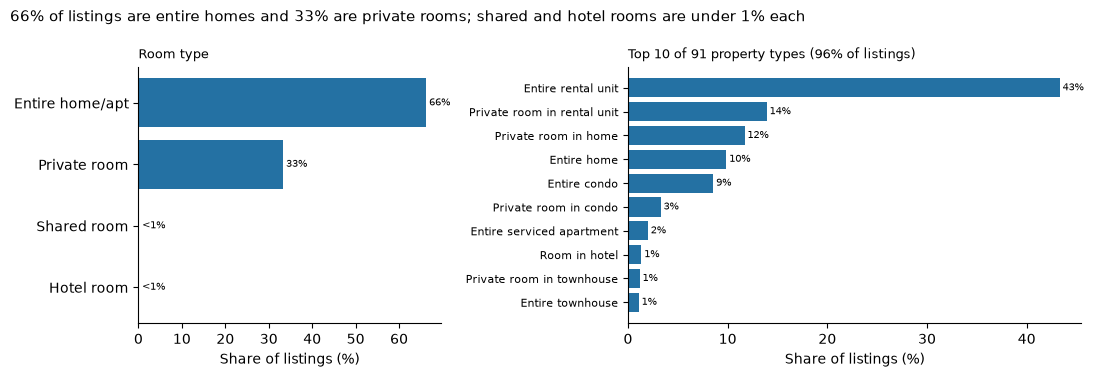

**Insight:** room type is dominated by two categories, so shared and hotel rooms (383 listings) are too small to compare reliably. `property_type` has a long tail of rare labels; grouping it into a few categories is better for modeling.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.5]})
room = (df["room_type"].value_counts(normalize=True) * 100).sort_values()
bar_pct(axes[0], room, horizontal=True)
axes[0].set_xlabel("Share of listings (%)")
axes[0].set_title("Room type", loc="left", fontsize=9)

prop = (df["property_type"].value_counts(normalize=True) * 100)
top10 = prop.head(10).sort_values()
bar_pct(axes[1], top10, horizontal=True)
axes[1].set_xlabel("Share of listings (%)")
axes[1].set_title(f"Top 10 of {df['property_type'].nunique()} property types "
                  f"({top10.sum():.0f}% of listings)", loc="left", fontsize=9)
axes[1].tick_params(axis="y", labelsize=8)

fig.suptitle(f"{room['Entire home/apt']:.0f}% of listings are entire homes and {room['Private room']:.0f}% are "
             f"private rooms; shared and hotel rooms are under 1% each", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig7_room_property_type.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** room type is dominated by two categories, so shared and hotel rooms "
    f"({(df['room_type'].isin(['Shared room', 'Hotel room'])).sum():,} listings) are too small to compare reliably. "
    f"`property_type` has a long tail of rare labels; grouping it into a few categories is better for modeling."))

## Figure 8: Listing size
Guest capacity, bedrooms, beds and bathrooms. Large values are grouped into a final "N+" bar.

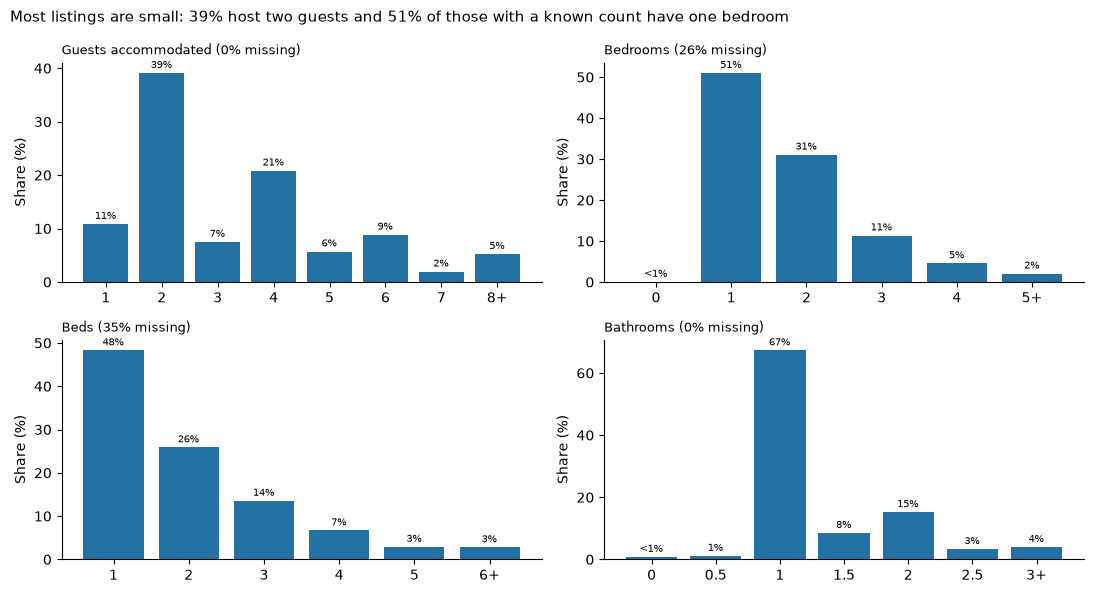

**Insight:** all four size variables are right-skewed, with a few large homes (up to 30 bedrooms and 50 beds). Guest capacity is even numbers for most listings (2, 4, 6). `bedrooms` and `beds` are missing for a quarter to a third of listings, so `accommodates` (complete) is the most reliable size measure.

In [6]:
size_specs = [("accommodates", 8, "Guests accommodated"), ("bedrooms", 5, "Bedrooms"),
              ("beds", 6, "Beds"), ("bathrooms", 3, "Bathrooms")]
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, (col, cap, label) in zip(axes.ravel(), size_specs):
    bar_pct(ax, bucket_counts(df[col], cap))
    ax.set_title(f"{label} ({df[col].isna().mean() * 100:.0f}% missing)", loc="left", fontsize=9)
    ax.set_ylabel("Share (%)")

acc = df["accommodates"].value_counts(normalize=True) * 100
bed1 = (df["bedrooms"].dropna() == 1).mean() * 100
fig.suptitle(f"Most listings are small: {acc[2]:.0f}% host two guests and {bed1:.0f}% of those with a "
             f"known count have one bedroom", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig8_listing_size.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** all four size variables are right-skewed, with a few large homes (up to "
    f"{df['bedrooms'].max():.0f} bedrooms and {df['beds'].max():.0f} beds). Guest capacity is even numbers "
    f"for most listings (2, 4, 6). `bedrooms` and `beds` are missing for a quarter to a third of listings, "
    f"so `accommodates` (complete) is the most reliable size measure."))

## Figure 9: Listings by borough
Count of listings in each of London's 33 boroughs (`neighbourhood_cleansed`).

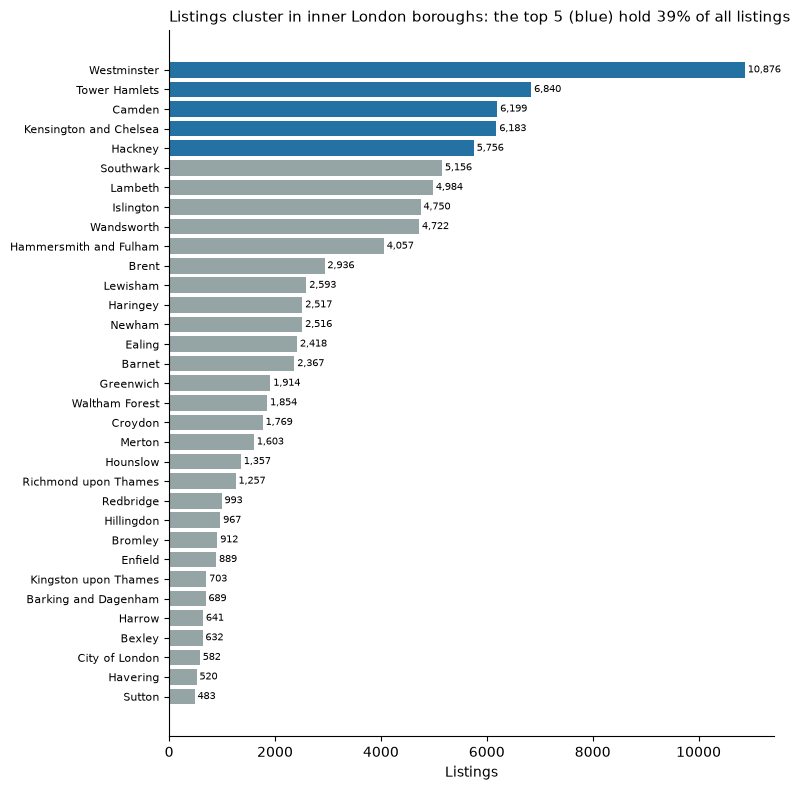

**Insight:** Westminster alone has 10,876 listings, about 23 times as many as Sutton (483). Borough samples are very uneven, so outer-borough comparisons in later parts rest on small groups.

In [7]:
nb = df["neighbourhood_cleansed"].value_counts().sort_values()
top5_share = nb.tail(5).sum() / nb.sum() * 100
fig, ax = plt.subplots(figsize=(8, 8))
bars = ax.barh(nb.index, nb.values, color=[BLUE if i >= len(nb) - 5 else GREY for i in range(len(nb))])
ax.bar_label(bars, labels=[f"{v:,}" for v in nb.values], padding=2, fontsize=7)
ax.set_xlabel("Listings")
ax.tick_params(axis="y", labelsize=8)
clean_axes(ax)
ax.set_title(f"Listings cluster in inner London boroughs: the top 5 (blue) hold {top5_share:.0f}% of all listings",
             loc="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig9_listings_by_borough.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** {nb.index[-1]} alone has {nb.iloc[-1]:,} listings, about {nb.iloc[-1] / nb.iloc[0]:.0f} times "
    f"as many as {nb.index[0]} ({nb.iloc[0]:,}). Borough samples are very uneven, so outer-borough "
    f"comparisons in later parts rest on small groups."))

## Figure 10: Booking rules and activity
Minimum stay, availability in the next 365 days, and total number of reviews.

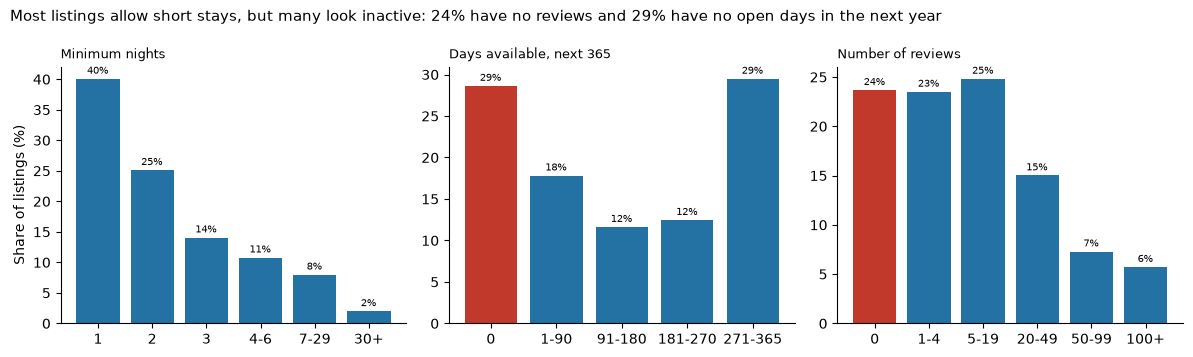

**Insight:** 79% of listings accept stays of 3 nights or fewer. Reviews are extremely skewed (median 5, max 1,959, skew 7), so review counts need a log scale. Listings with 0 available days are either fully booked or blocked by the host; the data cannot tell these apart.

In [8]:
def labelled_bins(s, bins, labels):
    return (pd.cut(s, bins=bins, labels=labels, right=True).value_counts(normalize=True) * 100).reindex(labels)

min_n = labelled_bins(df["minimum_nights"], [0, 1, 2, 3, 6, 29, np.inf], ["1", "2", "3", "4-6", "7-29", "30+"])
avail = labelled_bins(df["availability_365"], [-1, 0, 90, 180, 270, 365], ["0", "1-90", "91-180", "181-270", "271-365"])
revs = labelled_bins(df["number_of_reviews"], [-1, 0, 4, 19, 49, 99, np.inf], ["0", "1-4", "5-19", "20-49", "50-99", "100+"])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, share, title in zip(axes, [min_n, avail, revs],
                            ["Minimum nights", "Days available, next 365", "Number of reviews"]):
    bar_pct(ax, share, color=[RED if share.index[0] == lab and title != "Minimum nights" else BLUE
                              for lab in share.index])
    ax.set_title(title, loc="left", fontsize=9)
axes[0].set_ylabel("Share of listings (%)")

fig.suptitle(f"Most listings allow short stays, but many look inactive: {revs['0']:.0f}% have no reviews and "
             f"{avail['0']:.0f}% have no open days in the next year", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig10_booking_activity.png", dpi=500, bbox_inches="tight")
plt.show()

nr = df["number_of_reviews"]
display(Markdown(
    f"**Insight:** {(df['minimum_nights'] <= 3).mean() * 100:.0f}% of listings accept stays of 3 nights or fewer. "
    f"Reviews are extremely skewed (median {nr.median():.0f}, max {nr.max():,}, skew {nr.skew():.0f}), so review "
    f"counts need a log scale. Listings with 0 available days are either fully booked or blocked by the host; "
    f"the data cannot tell these apart."))

## Figure 11: Hosts
How many listings each host runs, how long they have hosted, and profile flags. Superhost is shown for context only; it is excluded from the model because it depends on the rating.

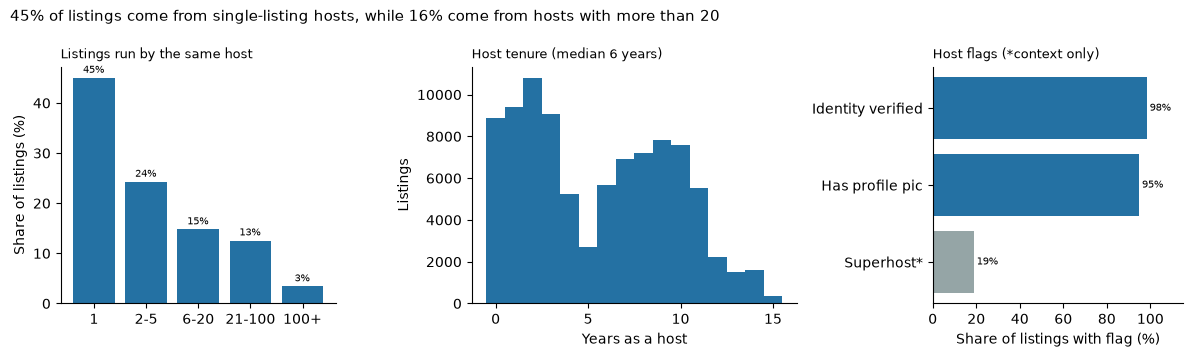

**Insight:** London has many professional multi-listing hosts (the largest runs 501 listings), so host type is worth testing in the bivariate part. Tenure has two peaks (about 2 and 9 years), suggesting a newer wave of hosts alongside long-standing ones. Identity verification (98%) and profile pictures (95%) are near-universal, so they carry little information for the model.

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.1, 1.3, 1]})

hl = labelled_bins(df["calculated_host_listings_count"], [0, 1, 5, 20, 100, np.inf],
                   ["1", "2-5", "6-20", "21-100", "100+"])
bar_pct(axes[0], hl)
axes[0].set_title("Listings run by the same host", loc="left", fontsize=9)
axes[0].set_ylabel("Share of listings (%)")

ten = df["hosts_time_as_host_years"].dropna()
axes[1].hist(ten, bins=np.arange(-0.5, ten.max() + 1.5, 1), color=BLUE)
axes[1].set_xlabel("Years as a host")
axes[1].set_ylabel("Listings")
axes[1].set_title(f"Host tenure (median {ten.median():.0f} years)", loc="left", fontsize=9)
clean_axes(axes[1])

flags = pd.Series({c: (df[c] == "t").mean() * 100 for c in
                   ["host_identity_verified", "host_has_profile_pic", "host_is_superhost"]})
flags.index = ["Identity verified", "Has profile pic", "Superhost*"]
bar_pct(axes[2], flags.sort_values(), color=[GREY, BLUE, BLUE], horizontal=True)
axes[2].set_xlim(0, 115)
axes[2].set_xlabel("Share of listings with flag (%)")
axes[2].set_title("Host flags (*context only)", loc="left", fontsize=9)

fig.suptitle(f"{hl['1']:.0f}% of listings come from single-listing hosts, while "
             f"{hl['21-100'] + hl['100+']:.0f}% come from hosts with more than 20", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig11_hosts.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** London has many professional multi-listing hosts (the largest runs "
    f"{df['calculated_host_listings_count'].max()} listings), so host type is worth testing in the bivariate part. "
    f"Tenure has two peaks (about 2 and 9 years), suggesting a newer wave of hosts alongside long-standing ones. "
    f"Identity verification ({flags['Identity verified']:.0f}%) and profile pictures ({flags['Has profile pic']:.0f}%) "
    f"are near-universal, so they carry little information for the model."))

## Figure 12: Amenities
Number of amenities listed per listing, and the most common amenities. `amenities` is stored as a JSON list in text.

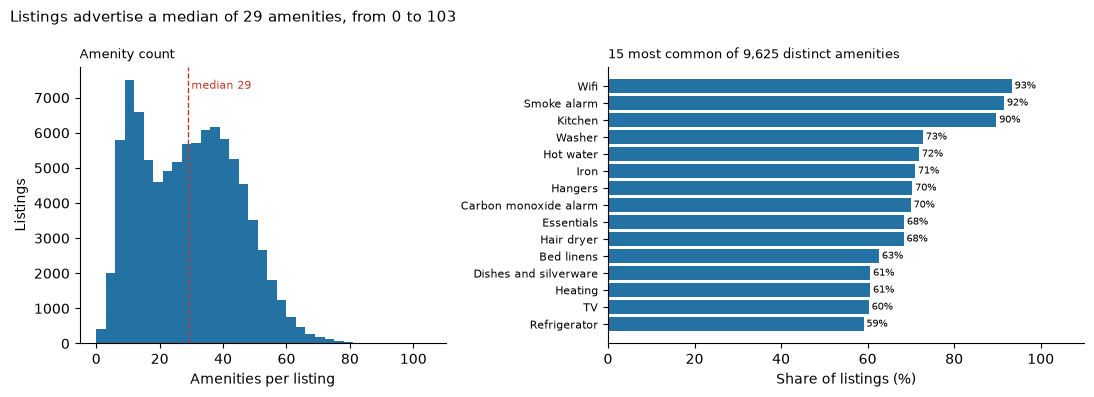

**Insight:** the count has two peaks (around 10 and around 40), and only 192 listings list none. The 9,625 distinct names include many free-text variants (brand names, sizes), so rarer amenities need grouping before use. Basics such as wifi appear on most listings, so they cannot separate top-rated listings. The amenity count, and rarer amenities, are better candidates for the next parts.

In [10]:
amen = df["amenities"].apply(lambda s: json.loads(s) if isinstance(s, str) else [])
n_amen = amen.str.len()
common = (amen.explode().value_counts() / len(df) * 100).head(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.3]})
axes[0].hist(n_amen, bins=np.arange(0, n_amen.max() + 3, 3), color=BLUE)
axes[0].axvline(n_amen.median(), color=RED, ls="--", lw=1)
axes[0].text(n_amen.median() + 1, axes[0].get_ylim()[1] * 0.92, f"median {n_amen.median():.0f}", fontsize=8, color=RED)
axes[0].set_xlabel("Amenities per listing")
axes[0].set_ylabel("Listings")
axes[0].set_title("Amenity count", loc="left", fontsize=9)
clean_axes(axes[0])

bar_pct(axes[1], common, horizontal=True)
axes[1].set_xlim(0, 110)
axes[1].set_xlabel("Share of listings (%)")
axes[1].set_title(f"15 most common of {amen.explode().nunique():,} distinct amenities", loc="left", fontsize=9)
axes[1].tick_params(axis="y", labelsize=8)

fig.suptitle(f"Listings advertise a median of {n_amen.median():.0f} amenities, from {n_amen.min()} to {n_amen.max()}",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig12_amenities.png", dpi=500, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** the count has two peaks (around 10 and around 40), and only {(n_amen == 0).sum():,} listings list none. "
    f"The {amen.explode().nunique():,} distinct names include many free-text variants (brand names, sizes), so "
    f"rarer amenities need grouping before use. Basics such as "
    f"{common.index[-1].lower()} appear on most listings, so they cannot separate top-rated listings. "
    f"The amenity count, and rarer amenities, are better candidates for the next parts."))

## Step 2: Outlier verdicts
The IQR fences in Step 1 flag thousands of listings, but most are the normal long tail. This step looks at the most extreme values one by one and decides whether each is **real**, a **data error** or a **policy value**, and what is done with it.

In [11]:
def top_row(col):
    return df.loc[df[col].idxmax()]

pr_max, bed_max, bath_max = top_row("price"), top_row("bedrooms"), top_row("bathrooms")
beds_max, rev_max, host_max = top_row("beds"), top_row("number_of_reviews"), top_row("calculated_host_listings_count")
mn = df["minimum_nights"]
hl_col = df["calculated_host_listings_count"]

display(Markdown(f"""
| Variable | Most extreme value | How many listings | Verdict | Action |
|---|---|---|---|---|
| `price` | £{pr_max['price']:,.0f} a night ({pr_max['room_type'].lower()}) | {(df['price'] > 5000).sum()} above £5,000; {(df['price'] > df['price_capped']).sum()} above the 99th-percentile cap | **Data error** above about £5,000 (placeholder or typo); real luxury listings between the cap and £5,000 | Capped at £{df['price_capped'].max():,.0f} in cleaning (`price_capped`), then log-transformed |
| `bedrooms` | {bed_max['bedrooms']:.0f} bedrooms for a {bed_max['accommodates']:.0f}-guest {bed_max['room_type'].lower()} ("{bed_max['name']}") | {(df['bedrooms'] >= 10).sum()} with 10 or more | **Data error**: the building's room count was entered, not the listing's | Kept, grouped into 5+ in charts and flagged (`size_extreme`) in cleaning; `accommodates` is the main size measure |
| `beds` | {beds_max['beds']:.0f} beds in a {beds_max['room_type'].lower()} for {beds_max['accommodates']:.0f} guests | {(df['beds'] > 2 * df['accommodates']).sum()} with more than 2 beds per guest | **Mixed**: real dormitory beds in hostels; errors where a private or hotel room lists dozens | Same as bedrooms: grouped into 6+ and flagged |
| `bathrooms` | {bath_max['bathrooms']:.0f} bathrooms for a {bath_max['accommodates']:.0f}-guest {bath_max['room_type'].lower()} | {(df['bathrooms'] >= 10).sum()} with 10 or more | **Data error**: building-level count | Grouped into 3+ and flagged |
| `minimum_nights` | {mn.max():,.0f} nights | {(mn > 365).sum()} above a year | **Policy value**: 1,125 is Airbnb's maximum setting, used to block bookings, not a real stay length | Capped at 365 (`minimum_nights_capped`) in cleaning; shown as a 30+ band |
| `number_of_reviews` | {rev_max['number_of_reviews']:,} reviews ({rev_max['reviews_per_month']:.0f} a month, {rev_max['room_type'].lower()}) | {n_outside(df['number_of_reviews']):,} above the IQR fence | **Real**: hotel-style rooms with very high turnover | Kept; log scale or bands |
| `calculated_host_listings_count` | {host_max['calculated_host_listings_count']} listings from one host | {(hl_col > 100).sum():,} listings belong to hosts with 100+ | **Real**: property-management companies | Kept; shown in bands, and host type is tested in the bivariate part |
| `review_scores_rating` | lowest score {rt.min():.1f} | {n_outside(rt):,} below the lower IQR fence ({iqr_fences(rt)[0]:.2f}) | **Real**: genuine guest scores | Kept; they belong to the below-4.8 class |
"""))
display(Markdown(
    "**Insight:** only the size counts and the extreme prices are errors, and both come from whole buildings or placeholders. "
    "Nothing is deleted: errors are capped or flagged so the listing stays in the sample, and real extremes "
    "(review counts, large hosts, low ratings) are kept because they describe real London listings."))


| Variable | Most extreme value | How many listings | Verdict | Action |
|---|---|---|---|---|
| `price` | £527,524 a night (entire home/apt) | 100 above £5,000; 623 above the 99th-percentile cap | **Data error** above about £5,000 (placeholder or typo); real luxury listings between the cap and £5,000 | Capped at £1,373 in cleaning (`price_capped`), then log-transformed |
| `bedrooms` | 30 bedrooms for a 1-guest private room ("King's College Stamford Street Apartments") | 31 with 10 or more | **Data error**: the building's room count was entered, not the listing's | Kept, grouped into 5+ in charts and flagged (`size_extreme`) in cleaning; `accommodates` is the main size measure |
| `beds` | 50 beds in a shared room for 16 guests | 156 with more than 2 beds per guest | **Mixed**: real dormitory beds in hostels; errors where a private or hotel room lists dozens | Same as bedrooms: grouped into 6+ and flagged |
| `bathrooms` | 30 bathrooms for a 2-guest private room | 28 with 10 or more | **Data error**: building-level count | Grouped into 3+ and flagged |
| `minimum_nights` | 1,125 nights | 25 above a year | **Policy value**: 1,125 is Airbnb's maximum setting, used to block bookings, not a real stay length | Capped at 365 (`minimum_nights_capped`) in cleaning; shown as a 30+ band |
| `number_of_reviews` | 1,959 reviews (32 a month, private room) | 10,574 above the IQR fence | **Real**: hotel-style rooms with very high turnover | Kept; log scale or bands |
| `calculated_host_listings_count` | 501 listings from one host | 3,148 listings belong to hosts with 100+ | **Real**: property-management companies | Kept; shown in bands, and host type is tested in the bivariate part |
| `review_scores_rating` | lowest score 1.0 | 2,840 below the lower IQR fence (4.00) | **Real**: genuine guest scores | Kept; they belong to the below-4.8 class |


**Insight:** only the size counts and the extreme prices are errors, and both come from whole buildings or placeholders. Nothing is deleted: errors are capped or flagged so the listing stays in the sample, and real extremes (review counts, large hosts, low ratings) are kept because they describe real London listings.

## Step 3: Missing data, mean or median
Price, bedrooms, beds and bathrooms have missing values. Before any filling, compare mean and median for each, overall and by room type.

In [12]:
miss_cols = ["price_capped", "bedrooms", "beds", "bathrooms"]
mm = pd.DataFrame({"missing_pct": df[miss_cols].isna().mean() * 100,
                   "mean": df[miss_cols].mean(),
                   "median": df[miss_cols].median(),
                   "skew": df[miss_cols].skew()})
mm["mean_above_median_pct"] = (mm["mean"] - mm["median"]) / mm["median"] * 100
display(mm.round(2))

by_room = df.groupby("room_type")[miss_cols].median()
display(by_room)

display(Markdown(
    f"**Decision: fill with the median, within each room type.** All four columns are right-skewed "
    f"(skew {mm['skew'].min():.1f} to {mm['skew'].max():.1f}), so the mean is pulled up by the long tail: mean price is "
    f"£{mm.at['price_capped', 'mean']:.0f} against a median of £{mm.at['price_capped', 'median']:.0f} "
    f"({mm.at['price_capped', 'mean_above_median_pct']:.0f}% higher), and mean bedrooms is {mm.at['bedrooms', 'mean']:.2f} against {mm.at['bedrooms', 'median']:.0f}. "
    f"Filling {mm.at['price_capped', 'missing_pct']:.0f}% of listings with the mean would push them toward luxury prices. "
    f"Medians also differ by room type (entire home £{by_room.at['Entire home/apt', 'price_capped']:.0f} vs private room "
    f"£{by_room.at['Private room', 'price_capped']:.0f}), so one overall median would overstate private rooms. "
    f"This matches `01_cleaning.ipynb`, which writes the filled values to new `*_imp` columns and adds `*_missing` flags. "
    f"The charts in this notebook use observed values only."))

,missing_pct,mean,median,skew,mean_above_median_pct
price_capped,32.81,244.37,180.0,2.54,35.76
bedrooms,25.89,1.77,1.0,2.92,76.79
beds,35.06,2.02,2.0,3.38,1.05
bathrooms,0.14,1.33,1.0,4.79,33.19


,price_capped,bedrooms,beds,bathrooms
room_type,,,,
Entire home/apt,239.50,2.0,2.0,1.0
Hotel room,156.00,1.0,1.0,1.0
Private room,82.34,1.0,1.0,1.0
Shared room,44.00,1.0,2.0,1.0


**Decision: fill with the median, within each room type.** All four columns are right-skewed (skew 2.5 to 4.8), so the mean is pulled up by the long tail: mean price is £244 against a median of £180 (36% higher), and mean bedrooms is 1.77 against 1. Filling 33% of listings with the mean would push them toward luxury prices. Medians also differ by room type (entire home £240 vs private room £82), so one overall median would overstate private rooms. This matches `01_cleaning.ipynb`, which writes the filled values to new `*_imp` columns and adds `*_missing` flags. The charts in this notebook use observed values only.

## Step 4: Decision table
Every choice made in this part, and why. Cleaning decisions are in `01_cleaning.ipynb`; this table only covers how each variable was analysed and shown.

In [13]:
sk = lambda c: df[c].skew()
display(Markdown(f"""
| Column / issue | Decision | Because |
|---|---|---|
| `review_scores_rating` | Plotted for the {len(rated):,} rated listings only; x-axis starts at 3.5 | {df['review_scores_rating'].isna().sum():,} unrated listings have no score; the {(rt < 3.5).mean() * 100:.1f}% below 3.5 would flatten the chart, so their share is stated in the axis label |
| `top_rated` | Shown as class shares; no resampling suggested | Classes are close to balanced ({target_share.iloc[1]:.0f}% vs {target_share.iloc[0]:.0f}%) |
| Price | Used `price_capped`; **log(price) chosen** for all later parts | Raw skew {p.skew():.2f} and kurtosis {p.kurt():.1f}; after the log, skew {lp.skew():.2f} and kurtosis {lp.kurt():.2f}, and the QQ plot follows the normal line |
| Price missing ({df['price'].isna().mean() * 100:.0f}%) | Left out of price charts; filled with the room-type median only as a model input, with a missing flag | These listings mostly cannot be booked, so observed prices describe the market; the flag lets the model separate them |
| `price_quote_price_per_night`, `price_quote_total_price` | Not analysed separately | Per-night quote equals `price` for all {df['price'].notna().sum():,} priced listings |
| `estimated_revenue_l365d` | Not analysed | Derived from price and estimated occupancy, so it repeats information already shown |
| `room_type` | All 4 categories kept and shown | Shared and hotel rooms are only {(df['room_type'].isin(['Shared room', 'Hotel room'])).sum():,} listings, so they are flagged as too small to compare, not dropped |
| `property_type` | Top 10 of {df['property_type'].nunique()} shown; grouping recommended | The top 10 cover {top10.sum():.0f}% of listings; the rest is a long tail of rare labels |
| `accommodates`, `bedrooms`, `beds`, `bathrooms` | Shown as counts with large values grouped (8+, 5+, 6+, 3+) | Rare extremes (up to {df['bedrooms'].max():.0f} bedrooms, {df['beds'].max():.0f} beds) would stretch the axis |
| `bedrooms` ({df['bedrooms'].isna().mean() * 100:.0f}% missing), `beds` ({df['beds'].isna().mean() * 100:.0f}% missing) | Missing share shown in panel titles; filled with the **median by room type** for modeling | Skewed, so the mean overstates the typical listing (Step 3); `accommodates` is complete and used as the main size measure |
| `neighbourhood_cleansed` | All {nb.size} boroughs shown, top 5 highlighted | Only {nb.size} categories, so nothing needs grouping; the uneven spread is itself the finding |
| `latitude`, `longitude` | Not plotted here | Location is covered by borough; point maps belong in the dashboard |
| `minimum_nights` | Grouped into bands (1, 2, 3, 4-6, 7-29, 30+) | Skew {sk('minimum_nights'):.0f}; max {df['minimum_nights'].max():,.0f} nights |
| `availability_365` | Grouped into bands, with 0 days highlighted | {(df['availability_365'] == 0).mean() * 100:.0f}% have 0 days, which can mean fully booked or blocked; the data cannot tell these apart |
| `number_of_reviews` | Grouped into bands, with 0 reviews highlighted | Skew {sk('number_of_reviews'):.0f}; median {nr.median():.0f} but max {nr.max():,} |
| `calculated_host_listings_count` used, `host_listings_count` not | Used the count from this snapshot | It is complete and counts London listings in this data; `host_listings_count` matches it for only {(df['host_listings_count'] == df['calculated_host_listings_count']).mean() * 100:.0f}% of listings |
| `hosts_time_as_host_years` | Used years; months column ignored | The months column only holds the remainder (0-11), so years alone shows the distribution |
| `host_identity_verified`, `host_has_profile_pic` | Described; flagged as low information | Near-universal ({(df['host_identity_verified'] == 't').mean() * 100:.0f}% and {(df['host_has_profile_pic'] == 't').mean() * 100:.0f}%) |
| `host_is_superhost` | Shown in Figure 11 as context only | Tied to the rating (leakage), so it must not be a model feature |
| Review sub-scores (`review_scores_accuracy` etc.) | Not plotted | Leakage; they are parts of the overall rating |
| Host response rate, acceptance rate, response time | Not analysed | Completely empty in this snapshot (dropped in cleaning) |
| `amenities` | Parsed from JSON text; count per listing and top 15 shown | {amen.explode().nunique():,} distinct free-text names; individual amenities need grouping before use |
| Kurtosis and IQR outliers | Computed for every numeric variable (Step 1) | Fence counts alone are not used to drop data, because most flagged points are the long tail of skewed variables |
| Extreme values | Verdict per variable (Step 2): errors capped or flagged, real extremes kept | No listing is deleted; capping keeps the sample while removing impossible values |
| `name`, `description`, `host_about` | Not analysed | Free text needs text processing, which is outside univariate EDA |
"""))


| Column / issue | Decision | Because |
|---|---|---|
| `review_scores_rating` | Plotted for the 70,708 rated listings only; x-axis starts at 3.5 | 21,927 unrated listings have no score; the 2.4% below 3.5 would flatten the chart, so their share is stated in the axis label |
| `top_rated` | Shown as class shares; no resampling suggested | Classes are close to balanced (56% vs 44%) |
| Price | Used `price_capped`; **log(price) chosen** for all later parts | Raw skew 2.54 and kurtosis 8.1; after the log, skew 0.09 and kurtosis -0.11, and the QQ plot follows the normal line |
| Price missing (33%) | Left out of price charts; filled with the room-type median only as a model input, with a missing flag | These listings mostly cannot be booked, so observed prices describe the market; the flag lets the model separate them |
| `price_quote_price_per_night`, `price_quote_total_price` | Not analysed separately | Per-night quote equals `price` for all 62,238 priced listings |
| `estimated_revenue_l365d` | Not analysed | Derived from price and estimated occupancy, so it repeats information already shown |
| `room_type` | All 4 categories kept and shown | Shared and hotel rooms are only 383 listings, so they are flagged as too small to compare, not dropped |
| `property_type` | Top 10 of 91 shown; grouping recommended | The top 10 cover 96% of listings; the rest is a long tail of rare labels |
| `accommodates`, `bedrooms`, `beds`, `bathrooms` | Shown as counts with large values grouped (8+, 5+, 6+, 3+) | Rare extremes (up to 30 bedrooms, 50 beds) would stretch the axis |
| `bedrooms` (26% missing), `beds` (35% missing) | Missing share shown in panel titles; filled with the **median by room type** for modeling | Skewed, so the mean overstates the typical listing (Step 3); `accommodates` is complete and used as the main size measure |
| `neighbourhood_cleansed` | All 33 boroughs shown, top 5 highlighted | Only 33 categories, so nothing needs grouping; the uneven spread is itself the finding |
| `latitude`, `longitude` | Not plotted here | Location is covered by borough; point maps belong in the dashboard |
| `minimum_nights` | Grouped into bands (1, 2, 3, 4-6, 7-29, 30+) | Skew 26; max 1,125 nights |
| `availability_365` | Grouped into bands, with 0 days highlighted | 29% have 0 days, which can mean fully booked or blocked; the data cannot tell these apart |
| `number_of_reviews` | Grouped into bands, with 0 reviews highlighted | Skew 7; median 5 but max 1,959 |
| `calculated_host_listings_count` used, `host_listings_count` not | Used the count from this snapshot | It is complete and counts London listings in this data; `host_listings_count` matches it for only 74% of listings |
| `hosts_time_as_host_years` | Used years; months column ignored | The months column only holds the remainder (0-11), so years alone shows the distribution |
| `host_identity_verified`, `host_has_profile_pic` | Described; flagged as low information | Near-universal (98% and 95%) |
| `host_is_superhost` | Shown in Figure 11 as context only | Tied to the rating (leakage), so it must not be a model feature |
| Review sub-scores (`review_scores_accuracy` etc.) | Not plotted | Leakage; they are parts of the overall rating |
| Host response rate, acceptance rate, response time | Not analysed | Completely empty in this snapshot (dropped in cleaning) |
| `amenities` | Parsed from JSON text; count per listing and top 15 shown | 9,625 distinct free-text names; individual amenities need grouping before use |
| Kurtosis and IQR outliers | Computed for every numeric variable (Step 1) | Fence counts alone are not used to drop data, because most flagged points are the long tail of skewed variables |
| Extreme values | Verdict per variable (Step 2): errors capped or flagged, real extremes kept | No listing is deleted; capping keeps the sample while removing impossible values |
| `name`, `description`, `host_about` | Not analysed | Free text needs text processing, which is outside univariate EDA |


## Step 5: Key takeaways for the next parts

In [14]:
display(Markdown(f"""
- **Target:** ratings are bunched at the top (median {rt.median():.2f}); the 4.8 cut gives balanced classes ({target_share.iloc[1]:.0f}% top rated).
- **Use log price:** raw price has skew {p.skew():.2f}; log price has skew {lp.skew():.2f}. Number of reviews, minimum nights and host listing count also have long right tails, so use log scales or bands.
- **Outliers:** extreme bedrooms, beds, bathrooms and prices above about £5,000 are data errors (capped or flagged); review counts, large hosts and low ratings are real and kept.
- **Sparse categories:** shared and hotel rooms, rare property types and small outer boroughs have few listings. Group them before comparing.
- **Low-information features:** identity verification and profile pictures are near-universal.
- **Missing data:** price ({df['price'].isna().mean() * 100:.0f}%), bedrooms ({df['bedrooms'].isna().mean() * 100:.0f}%) and beds ({df['beds'].isna().mean() * 100:.0f}%) are filled with room-type medians, not means, with a missing flag kept.
- **Candidates for the bivariate part:** room type, price, size (`accommodates`), borough, host type (single vs multi-listing), host tenure, amenity count and minimum nights.
"""))


- **Target:** ratings are bunched at the top (median 4.83); the 4.8 cut gives balanced classes (56% top rated).
- **Use log price:** raw price has skew 2.54; log price has skew 0.09. Number of reviews, minimum nights and host listing count also have long right tails, so use log scales or bands.
- **Outliers:** extreme bedrooms, beds, bathrooms and prices above about £5,000 are data errors (capped or flagged); review counts, large hosts and low ratings are real and kept.
- **Sparse categories:** shared and hotel rooms, rare property types and small outer boroughs have few listings. Group them before comparing.
- **Low-information features:** identity verification and profile pictures are near-universal.
- **Missing data:** price (33%), bedrooms (26%) and beds (35%) are filled with room-type medians, not means, with a missing flag kept.
- **Candidates for the bivariate part:** room type, price, size (`accommodates`), borough, host type (single vs multi-listing), host tenure, amenity count and minimum nights.


## Step 6: CPU timing
Times the two figures that best answer the project question (*which listing and host features predict a top rating of 4.8 or higher, so hosts know what to improve first?*):
- **Figure 11, Hosts:** host profile is the strongest feature group in the multivariate model (Figure 19), and the number of listings a host runs is the single most important feature.
- **Figure 12, Amenities:** amenities are the strongest feature group a host can change, so they are where hosts should look first.

Each figure is timed end to end: data preparation (pandas) and drawing (matplotlib, same code as above). The chart is drawn in memory but not shown or saved, so display and file writing are not counted. Loading the CSV is timed separately.

In [15]:
import time, platform
from contextlib import contextmanager

times = []

@contextmanager
def timer(label):
    t0 = time.perf_counter()
    yield
    times.append({"Step": label, "Seconds (CPU)": round(time.perf_counter() - t0, 3)})


def render(fig):
    # Draw the finished figure in memory, then close it so nothing is displayed or saved
    fig.canvas.draw()
    plt.close(fig)


with timer("Load CSV"):
    tdf = pd.read_csv("../data/listings_clean.csv", low_memory=False)

# Figure 11: Hosts
with timer("Fig 11: data prep (host bands, tenure, flags)"):
    t_hl = labelled_bins(tdf["calculated_host_listings_count"], [0, 1, 5, 20, 100, np.inf],
                         ["1", "2-5", "6-20", "21-100", "100+"])
    t_ten = tdf["hosts_time_as_host_years"].dropna()
    t_flags = pd.Series({c: (tdf[c] == "t").mean() * 100 for c in
                         ["host_identity_verified", "host_has_profile_pic", "host_is_superhost"]})
    t_flags.index = ["Identity verified", "Has profile pic", "Superhost*"]

with timer("Fig 11: draw chart"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.1, 1.3, 1]})
    bar_pct(axes[0], t_hl)
    axes[0].set_title("Listings run by the same host", loc="left", fontsize=9)
    axes[0].set_ylabel("Share of listings (%)")
    axes[1].hist(t_ten, bins=np.arange(-0.5, t_ten.max() + 1.5, 1), color=BLUE)
    axes[1].set_xlabel("Years as a host")
    axes[1].set_ylabel("Listings")
    axes[1].set_title(f"Host tenure (median {t_ten.median():.0f} years)", loc="left", fontsize=9)
    clean_axes(axes[1])
    bar_pct(axes[2], t_flags.sort_values(), color=[GREY, BLUE, BLUE], horizontal=True)
    axes[2].set_xlim(0, 115)
    axes[2].set_xlabel("Share of listings with flag (%)")
    axes[2].set_title("Host flags (*context only)", loc="left", fontsize=9)
    fig.suptitle(f"{t_hl['1']:.0f}% of listings come from single-listing hosts, while "
                 f"{t_hl['21-100'] + t_hl['100+']:.0f}% come from hosts with more than 20", x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    render(fig)

# Figure 12: Amenities
with timer("Fig 12: data prep (parse JSON, count, top 15)"):
    t_amen = tdf["amenities"].apply(lambda s: json.loads(s) if isinstance(s, str) else [])
    t_n = t_amen.str.len()
    t_exp = t_amen.explode()
    t_common = (t_exp.value_counts() / len(tdf) * 100).head(15).sort_values()
    t_distinct = t_exp.nunique()

with timer("Fig 12: draw chart"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.3]})
    axes[0].hist(t_n, bins=np.arange(0, t_n.max() + 3, 3), color=BLUE)
    axes[0].axvline(t_n.median(), color=RED, ls="--", lw=1)
    axes[0].text(t_n.median() + 1, axes[0].get_ylim()[1] * 0.92, f"median {t_n.median():.0f}", fontsize=8, color=RED)
    axes[0].set_xlabel("Amenities per listing")
    axes[0].set_ylabel("Listings")
    axes[0].set_title("Amenity count", loc="left", fontsize=9)
    clean_axes(axes[0])
    bar_pct(axes[1], t_common, horizontal=True)
    axes[1].set_xlim(0, 110)
    axes[1].set_xlabel("Share of listings (%)")
    axes[1].set_title(f"15 most common of {t_distinct:,} distinct amenities", loc="left", fontsize=9)
    axes[1].tick_params(axis="y", labelsize=8)
    fig.suptitle(f"Listings advertise a median of {t_n.median():.0f} amenities, from {t_n.min()} to {t_n.max()}",
                 x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    render(fig)

timing = pd.DataFrame(times)
for f in ["Fig 11", "Fig 12"]:
    s = timing.loc[timing["Step"].str.startswith(f), "Seconds (CPU)"].sum()
    timing.loc[len(timing)] = {"Step": f"{f}: total (prep + draw)", "Seconds (CPU)": round(s, 3)}
timing.loc[len(timing)] = {"Step": "Total", "Seconds (CPU)": round(sum(t["Seconds (CPU)"] for t in times), 3)}
timing.to_csv("../docs/timing_univariate_cpu.csv", index=False)
print("Machine:", platform.platform())
display(timing)

f11 = timing.set_index("Step")["Seconds (CPU)"]
display(Markdown(
    f"**Insight:** loading the CSV takes {f11['Load CSV'] / f11['Total'] * 100:.0f}% of the total. "
    f"Figure 11 is fast to prepare ({f11['Fig 11: data prep (host bands, tenure, flags)']:.3f} s), so most of its time is drawing. "
    f"Figure 12 is the slowest figure: parsing the amenities text for {len(tdf):,} listings takes "
    f"{f11['Fig 12: data prep (parse JSON, count, top 15)']:.3f} s, "
    f"{f11['Fig 12: data prep (parse JSON, count, top 15)'] / f11['Fig 12: total (prep + draw)'] * 100:.0f}% of that figure's time."))

Machine: Windows-11-10.0.26200-SP0


,Step,Seconds (CPU)
0,Load CSV,2.391
1,"Fig 11: data prep (host bands, tenure, flags)",0.012
2,Fig 11: draw chart,0.140
3,"Fig 12: data prep (parse JSON, count, top 15)",1.016
4,Fig 12: draw chart,0.173
5,Fig 11: total (prep + draw),0.152
6,Fig 12: total (prep + draw),1.189
7,Total,3.732


**Insight:** loading the CSV takes 64% of the total. Figure 11 is fast to prepare (0.012 s), so most of its time is drawing. Figure 12 is the slowest figure: parsing the amenities text for 92,635 listings takes 1.016 s, 85% of that figure's time.